In [2]:
import pandas as pd

training_df = pd.read_csv(
    "../data/processed/amazon_training_data.csv"
)

print("Training examples:", len(training_df))
print(training_df["intent"].value_counts())

Training examples: 567
intent
delivery_issue                  148
other_support                    81
refund                           46
return_replacement               43
account_access                   36
payment_billing                  33
order_status                     32
order_cancellation               29
prime_membership                 28
product_issue                    24
product_availability_pricing     24
seller_marketplace               23
delivery_address_options         20
Name: count, dtype: int64


In [3]:
%pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [4]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Embedding model loaded.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding model loaded.


In [5]:
import sys

print("Python being used:")
print(sys.executable)

Python being used:
C:\Users\sujat\OneDrive\Desktop\Hiver\.venv\Scripts\python.exe


In [6]:
training_embeddings = embedding_model.encode(
    training_df["text"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Embedding shape:", training_embeddings.shape)

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Embedding shape: (567, 384)


In [7]:
from sklearn.model_selection import train_test_split

indices = list(range(len(training_df)))

train_indices, test_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=training_df["intent"]
)

X_train_emb = training_embeddings[train_indices]
X_test_emb = training_embeddings[test_indices]

y_train_emb = training_df.iloc[train_indices]["intent"]
y_test_emb = training_df.iloc[test_indices]["intent"]

print("Embedding training:", len(X_train_emb))
print("Embedding test:", len(X_test_emb))

Embedding training: 453
Embedding test: 114


In [8]:
from sklearn.linear_model import LogisticRegression

embedding_classifier = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

embedding_classifier.fit(
    X_train_emb,
    y_train_emb
)

print("Embedding classifier trained.")

Embedding classifier trained.


In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

embedding_pred = embedding_classifier.predict(X_test_emb)

embedding_accuracy = accuracy_score(
    y_test_emb,
    embedding_pred
)

embedding_precision, embedding_recall, embedding_f1, _ = (
    precision_recall_fscore_support(
        y_test_emb,
        embedding_pred,
        average="macro",
        zero_division=0
    )
)

print(f"Embedding Accuracy: {embedding_accuracy:.4f}")
print(f"Embedding Macro Precision: {embedding_precision:.4f}")
print(f"Embedding Macro Recall: {embedding_recall:.4f}")
print(f"Embedding Macro F1: {embedding_f1:.4f}")

Embedding Accuracy: 0.4737
Embedding Macro Precision: 0.4633
Embedding Macro Recall: 0.4926
Embedding Macro F1: 0.4600


In [10]:
comparison = pd.DataFrame({
    "Model": [
        "Word + Character TF-IDF + Logistic Regression",
        "Sentence Embeddings + Logistic Regression"
    ],
    "Accuracy": [
        0.4825,
        embedding_accuracy
    ],
    "Macro F1": [
        0.4145,
        embedding_f1
    ]
})

display(comparison)

,Model,Accuracy,Macro F1
0,Word + Character TF-IDF + Logistic Regression,0.482500,0.414500
1,Sentence Embeddings + Logistic Regression,0.473684,0.459951


In [11]:
print(
    classification_report(
        y_test_emb,
        embedding_pred,
        zero_division=0
    )
)

                              precision    recall  f1-score   support

              account_access       0.80      0.57      0.67         7
    delivery_address_options       0.00      0.00      0.00         4
              delivery_issue       0.59      0.33      0.43        30
          order_cancellation       0.71      0.83      0.77         6
                order_status       0.21      0.50      0.30         6
               other_support       0.64      0.56      0.60        16
             payment_billing       0.83      0.71      0.77         7
            prime_membership       0.50      0.50      0.50         6
product_availability_pricing       0.45      1.00      0.62         5
               product_issue       0.00      0.00      0.00         5
                      refund       0.50      0.56      0.53         9
          return_replacement       0.38      0.33      0.35         9
          seller_marketplace       0.40      0.50      0.44         4

                  

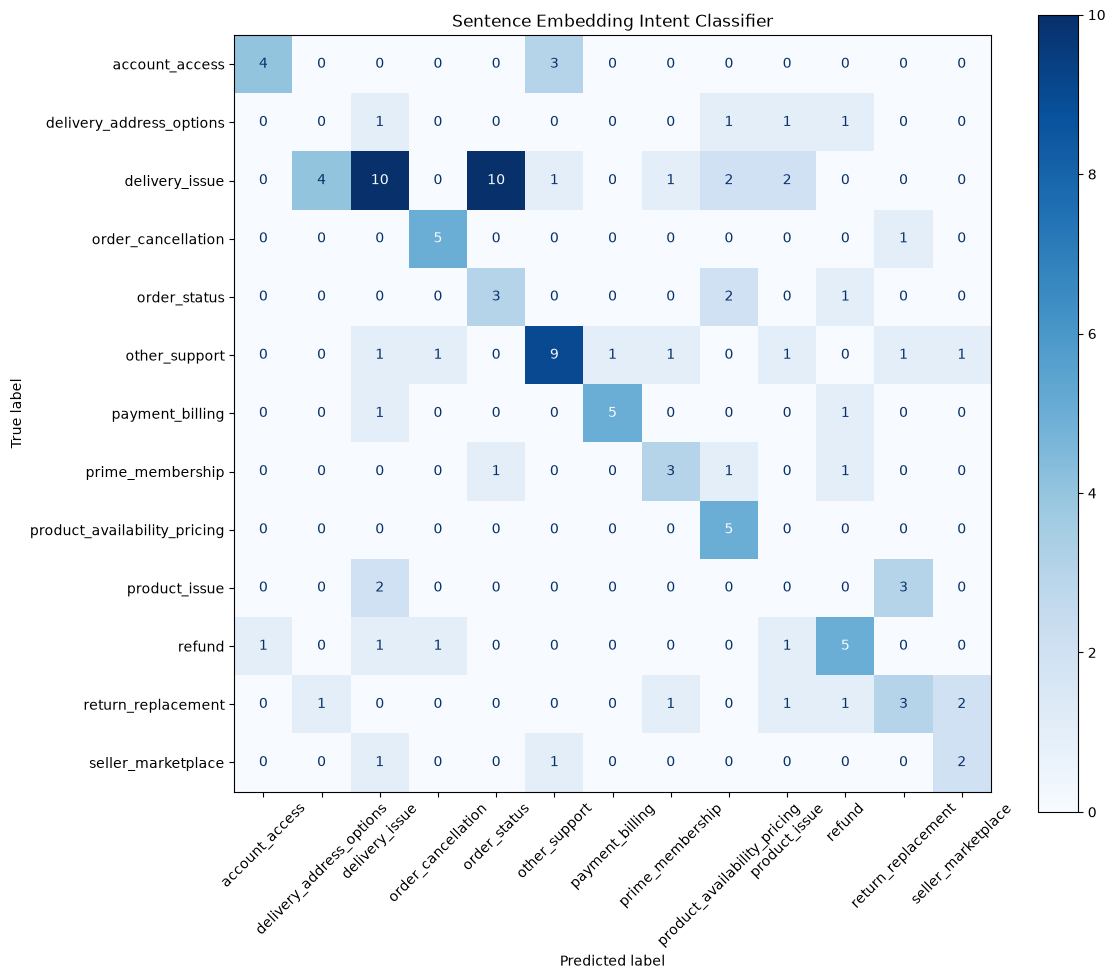

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test_emb,
    embedding_pred,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax
)

plt.title("Sentence Embedding Intent Classifier")
plt.tight_layout()
plt.show()

In [13]:
embedding_results = pd.DataFrame({
    "text": training_df.iloc[test_indices]["text"].values,
    "actual": y_test_emb.values,
    "predicted": embedding_pred
})

embedding_results["correct"] = (
    embedding_results["actual"] ==
    embedding_results["predicted"]
)

print("Correct:", embedding_results["correct"].sum())
print("Incorrect:", (~embedding_results["correct"]).sum())

display(
    embedding_results[
        ~embedding_results["correct"]
    ].head(30)
)

Correct: 54
Incorrect: 60


,text,actual,predicted,correct
0,@AmazonHelp My order 404-2520572-2629964. Arts...,product_issue,return_replacement,False
2,@AmazonHelp Im not returning this cause the sh...,product_issue,return_replacement,False
3,@AmazonHelp Okay waiting to hear back. There h...,return_replacement,refund,False
4,@AmazonHelp At 23.55 the system said I request...,delivery_issue,order_status,False
8,"@AmazonHelp Thanks, I don't want to return it ...",product_issue,return_replacement,False
9,@AmazonHelp Let me tell you - I ported to a di...,delivery_issue,delivery_address_options,False
11,@AmazonHelp What is the purpose of having amaz...,product_issue,delivery_issue,False
15,@AmazonHelp I ordered from .com,other_support,seller_marketplace,False
16,@AmazonHelp The product wasn't damaged but tha...,delivery_issue,product_issue,False
19,@AmazonHelp Worst and pathetic service by @115...,seller_marketplace,other_support,False


In [14]:
training_distribution = (
    training_df["intent"]
    .value_counts()
    .sort_values()
)

display(training_distribution)

intent
delivery_address_options         20
seller_marketplace               23
product_issue                    24
product_availability_pricing     24
prime_membership                 28
order_cancellation               29
order_status                     32
payment_billing                  33
account_access                   36
return_replacement               43
refund                           46
other_support                    81
delivery_issue                  148
Name: count, dtype: int64

In [15]:
print("Smallest intent:", training_distribution.index[0])
print("Smallest count:", training_distribution.iloc[0])

Smallest intent: delivery_address_options
Smallest count: 20


In [16]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
import numpy as np

# Use the same train/test split already created above
train_emb_df = pd.DataFrame({
    "text": X_train_emb.index if hasattr(X_train_emb, "index") else range(len(X_train_emb)),
    "intent": y_train_emb.values
})

# Check class distribution in the training portion
train_class_counts = y_train_emb.value_counts().sort_values()

display(train_class_counts)

intent
delivery_address_options         16
product_issue                    19
product_availability_pricing     19
seller_marketplace               19
prime_membership                 22
order_cancellation               23
payment_billing                  26
order_status                     26
account_access                   29
return_replacement               34
refund                           37
other_support                    65
delivery_issue                  118
Name: count, dtype: int64

In [17]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

embedding_svm = LinearSVC(
    class_weight="balanced",
    C=1.0,
    random_state=42
)

embedding_svm.fit(X_train_emb, y_train_emb)

y_pred_svm = embedding_svm.predict(X_test_emb)

accuracy_svm = accuracy_score(y_test_emb, y_pred_svm)

precision_svm, recall_svm, f1_svm, _ = precision_recall_fscore_support(
    y_test_emb,
    y_pred_svm,
    average="macro",
    zero_division=0
)

print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Macro Precision: {precision_svm:.4f}")
print(f"Macro Recall: {recall_svm:.4f}")
print(f"Macro F1: {f1_svm:.4f}")

print("\nClassification Report:\n")
print(classification_report(
    y_test_emb,
    y_pred_svm,
    zero_division=0
))

Accuracy: 0.4825
Macro Precision: 0.4391
Macro Recall: 0.4553
Macro F1: 0.4394

Classification Report:

                              precision    recall  f1-score   support

              account_access       0.57      0.57      0.57         7
    delivery_address_options       0.00      0.00      0.00         4
              delivery_issue       0.54      0.50      0.52        30
          order_cancellation       0.57      0.67      0.62         6
                order_status       0.12      0.17      0.14         6
               other_support       0.47      0.50      0.48        16
             payment_billing       0.71      0.71      0.71         7
            prime_membership       0.75      0.50      0.60         6
product_availability_pricing       0.40      0.80      0.53         5
               product_issue       0.00      0.00      0.00         5
                      refund       0.44      0.44      0.44         9
          return_replacement       0.62      0.56      

In [18]:
# Recreate the original text train/test split
from sklearn.model_selection import train_test_split

X_text = training_df["text"]
y_text = training_df["intent"]

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text,
    y_text,
    test_size=0.20,
    random_state=42,
    stratify=y_text
)

print("Test messages:", len(X_test_text))


Test messages: 114


In [19]:
# Generate predictions from the embedding Logistic Regression model

y_pred_embedding = embedding_classifier.predict(X_test_emb)

print("Predictions generated:", len(y_pred_embedding))

Predictions generated: 114


In [20]:
error_analysis = pd.DataFrame({
    "text": X_test_text.reset_index(drop=True),
    "actual": y_test_text.reset_index(drop=True),
    "predicted": y_pred_embedding
})

errors = error_analysis[
    error_analysis["actual"] != error_analysis["predicted"]
].copy()

print(f"Total test examples: {len(error_analysis)}")
print(f"Incorrect predictions: {len(errors)}")
print(f"Error rate: {len(errors) / len(error_analysis):.2%}")

display(errors.head(30))

Total test examples: 114
Incorrect predictions: 60
Error rate: 52.63%


,text,actual,predicted
0,@AmazonHelp My order 404-2520572-2629964. Arts...,product_issue,return_replacement
2,@AmazonHelp Im not returning this cause the sh...,product_issue,return_replacement
3,@AmazonHelp Okay waiting to hear back. There h...,return_replacement,refund
4,@AmazonHelp At 23.55 the system said I request...,delivery_issue,order_status
8,"@AmazonHelp Thanks, I don't want to return it ...",product_issue,return_replacement
9,@AmazonHelp Let me tell you - I ported to a di...,delivery_issue,delivery_address_options
11,@AmazonHelp What is the purpose of having amaz...,product_issue,delivery_issue
15,@AmazonHelp I ordered from .com,other_support,seller_marketplace
16,@AmazonHelp The product wasn't damaged but tha...,delivery_issue,product_issue
19,@AmazonHelp Worst and pathetic service by @115...,seller_marketplace,other_support


In [21]:
confusion_pairs = (
    errors.groupby(["actual", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(confusion_pairs)

,actual,predicted,count
6,delivery_issue,order_status,10
5,delivery_issue,delivery_address_options,4
0,account_access,other_support,3
27,product_issue,return_replacement,3
9,delivery_issue,product_availability_pricing,2
10,delivery_issue,product_issue,2
12,order_status,product_availability_pricing,2
26,product_issue,delivery_issue,2
36,return_replacement,seller_marketplace,2
1,delivery_address_options,delivery_issue,1


In [22]:
import pandas as pd

# Load the cleaned AmazonHelp customer messages
customer_df = pd.read_csv(
    "../data/processed/amazon_clean.csv"
)

# Keep only customer messages
customer_df = customer_df[
    customer_df["inbound"] == True
].copy()

print("Total clean customer messages:", len(customer_df))

# IDs already used for model training
training_ids = set(training_df["tweet_id"])

# Remove training examples from the evaluation pool
available_for_evaluation = customer_df[
    ~customer_df["tweet_id"].isin(training_ids)
].copy()

print("Available for fresh evaluation:", len(available_for_evaluation))

Total clean customer messages: 100503
Available for fresh evaluation: 99936


In [23]:
# Create a fresh candidate pool for final human evaluation

import numpy as np

# Work only with messages never used in training
evaluation_pool = available_for_evaluation[
    ["tweet_id", "created_at", "text"]
].copy()

# Remove obvious acknowledgement-only messages
acknowledgements = {
    "yes", "yes.", "no", "no.", "ok", "ok.", "okay", "okay.",
    "thanks", "thanks!", "thanks.", "thank you", "thank you!",
    "thank you.", "done", "done!", "done.", "sent", "merci",
    "gracias", "oui"
}

def is_substantive(text):
    text = str(text).strip()
    cleaned = text.lower().replace("@amazonhelp", "").strip()
    cleaned = cleaned.strip(" .,!?:;-")
    
    if len(cleaned) < 15:
        return False
    
    if cleaned in acknowledgements:
        return False
    
    return True

evaluation_pool = evaluation_pool[
    evaluation_pool["text"].apply(is_substantive)
].copy()

print("Fresh substantive messages available:", len(evaluation_pool))

Fresh substantive messages available: 92895


In [24]:
# Generate model predictions for the fresh evaluation pool

evaluation_texts = evaluation_pool["text"].tolist()

evaluation_embeddings = embedding_model.encode(
    evaluation_texts,
    show_progress_bar=True
)

evaluation_predictions = embedding_classifier.predict(
    evaluation_embeddings
)

evaluation_pool["predicted_intent"] = evaluation_predictions

print("Predictions generated:", len(evaluation_pool))

Batches:   0%|          | 0/2903 [00:00<?, ?it/s]

Predictions generated: 92895


In [25]:
evaluation_distribution = (
    evaluation_pool["predicted_intent"]
    .value_counts()
    .sort_values()
)

display(evaluation_distribution)

predicted_intent
order_cancellation               2137
payment_billing                  2373
prime_membership                 2579
delivery_address_options         2650
return_replacement               3018
seller_marketplace               3121
account_access                   4108
refund                           4348
product_availability_pricing     4549
product_issue                    5489
order_status                     6053
delivery_issue                   9504
other_support                   42966
Name: count, dtype: int64

In [26]:
# Select 8 fresh evaluation examples per predicted intent

evaluation_sample = (
    evaluation_pool
    .groupby("predicted_intent", group_keys=False)
    .sample(n=8, random_state=42)
    .reset_index(drop=True)
)

print("Evaluation sample size:", len(evaluation_sample))

display(
    evaluation_sample["predicted_intent"]
    .value_counts()
    .sort_index()
)

Evaluation sample size: 104


predicted_intent
account_access                  8
delivery_address_options        8
delivery_issue                  8
order_cancellation              8
order_status                    8
other_support                   8
payment_billing                 8
prime_membership                8
product_availability_pricing    8
product_issue                   8
refund                          8
return_replacement              8
seller_marketplace              8
Name: count, dtype: int64

In [27]:
# Save the fresh evaluation dataset

evaluation_sample.to_csv(
    "../data/processed/amazon_final_evaluation_104.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


In [28]:
# Prepare the fresh evaluation set for independent human labeling

evaluation_file = "../data/processed/amazon_final_evaluation_104.csv"

eval_df = pd.read_csv(evaluation_file)

# Add blank columns for independent evaluation
eval_df["human_intent"] = ""
eval_df["correct"] = ""

# Save the labeling version
eval_df.to_csv(
    "../data/processed/amazon_final_evaluation_104.csv",
    index=False
)

print("Rows:", len(eval_df))
print("Columns:", list(eval_df.columns))

Rows: 104
Columns: ['tweet_id', 'created_at', 'text', 'predicted_intent', 'human_intent', 'correct']


In [31]:
import pandas as pd

path = "../data/processed/amazon_final_evaluation_104_filled.csv"

test_df = pd.read_csv(path)

print("Rows:", len(test_df))
print("Columns:", list(test_df.columns))

Rows: 104
Columns: ['tweet_id', 'created_at', 'text', 'predicted_intent', 'human_intent', 'correct']


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)
import pandas as pd

# Load the completed evaluation file
final_eval = pd.read_csv(
    "../data/processed/amazon_final_evaluation_104_filled.csv"
)

# Ground truth = human-reviewed labels
y_true = final_eval["human_intent"]

# Model predictions
y_pred_final = final_eval["predicted_intent"]

# Metrics
accuracy = accuracy_score(y_true, y_pred_final)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred_final,
    average="macro",
    zero_division=0
)

print(f"Evaluation examples: {len(final_eval)}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")
print(f"Macro F1: {f1:.4f}")

print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred_final,
    zero_division=0
))

Evaluation examples: 104
Accuracy: 0.7019
Macro Precision: 0.7019
Macro Recall: 0.8281
Macro F1: 0.7231

Classification Report:

                              precision    recall  f1-score   support

              account_access       0.50      1.00      0.67         4
    delivery_address_options       0.38      0.75      0.50         4
              delivery_issue       1.00      0.38      0.55        21
          order_cancellation       0.88      1.00      0.93         7
                order_status       0.88      1.00      0.93         7
               other_support       0.62      0.28      0.38        18
             payment_billing       0.88      1.00      0.93         7
            prime_membership       0.88      1.00      0.93         7
product_availability_pricing       0.50      0.67      0.57         6
               product_issue       0.62      0.83      0.71         6
                      refund       0.88      1.00      0.93         7
          return_replacement  

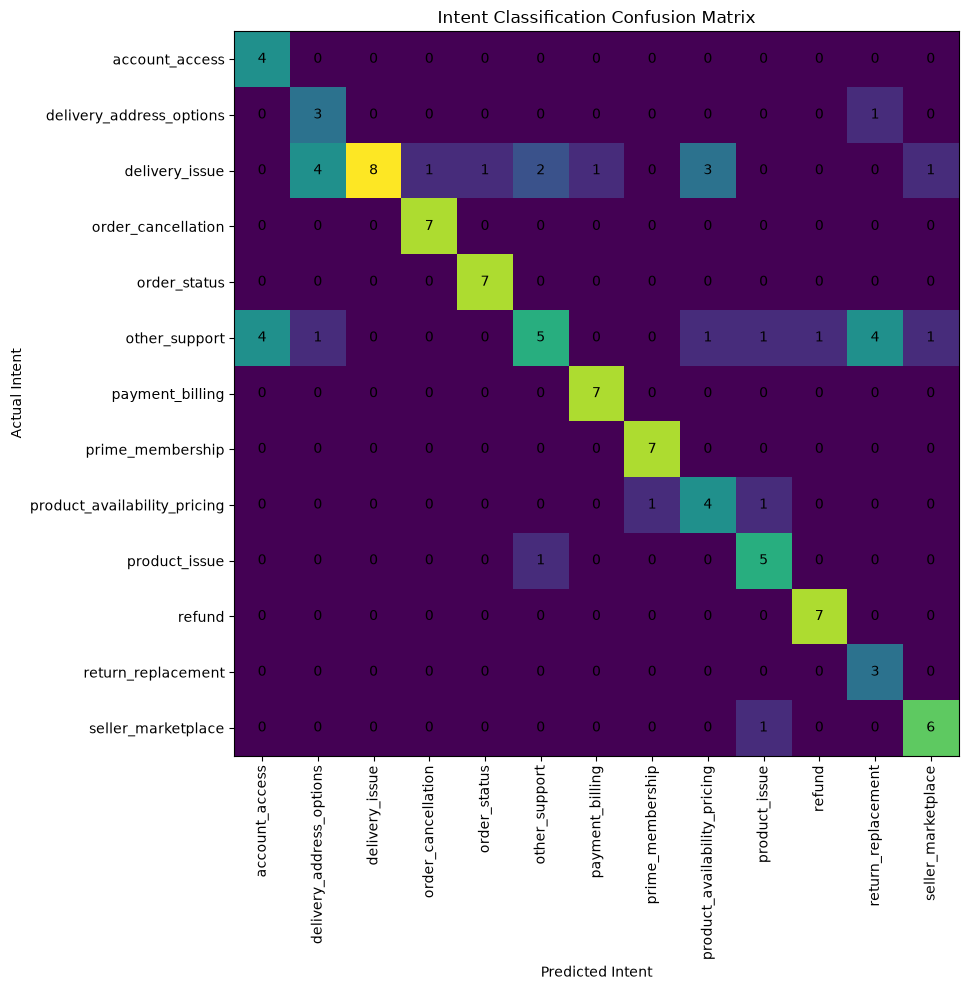

In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

labels = sorted(y_true.unique())

cm = confusion_matrix(
    y_true,
    y_pred_final,
    labels=labels
)

plt.figure(figsize=(12, 10))
plt.imshow(cm)

plt.xticks(
    np.arange(len(labels)),
    labels,
    rotation=90
)

plt.yticks(
    np.arange(len(labels)),
    labels
)

plt.xlabel("Predicted Intent")
plt.ylabel("Actual Intent")
plt.title("Intent Classification Confusion Matrix")

# Display values inside cells
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [34]:
# Save final evaluation results

final_eval.to_csv(
    "../data/processed/amazon_final_evaluation_104_filled.csv",
    index=False
)

print("Final evaluation saved.")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {f1:.4f}")

Final evaluation saved.
Accuracy: 0.7019
Macro F1: 0.7231


In [35]:
# Save confusion matrix as a CSV for the final report

confusion_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

confusion_df.to_csv(
    "../data/processed/intent_confusion_matrix.csv"
)

display(confusion_df)

,account_access,delivery_address_options,delivery_issue,order_cancellation,order_status,other_support,payment_billing,prime_membership,product_availability_pricing,product_issue,refund,return_replacement,seller_marketplace
account_access,4,0,0,0,0,0,0,0,0,0,0,0,0
delivery_address_options,0,3,0,0,0,0,0,0,0,0,0,1,0
delivery_issue,0,4,8,1,1,2,1,0,3,0,0,0,1
order_cancellation,0,0,0,7,0,0,0,0,0,0,0,0,0
order_status,0,0,0,0,7,0,0,0,0,0,0,0,0
other_support,4,1,0,0,0,5,0,0,1,1,1,4,1
payment_billing,0,0,0,0,0,0,7,0,0,0,0,0,0
prime_membership,0,0,0,0,0,0,0,7,0,0,0,0,0
product_availability_pricing,0,0,0,0,0,0,0,1,4,1,0,0,0
product_issue,0,0,0,0,0,1,0,0,0,5,0,0,0


In [36]:
import pandas as pd

conversations = pd.read_csv(
    "../data/processed/amazon_conversations.csv"
)

print("Rows:", len(conversations))
print("Columns:")
print(conversations.columns.tolist())

display(conversations.head())

Rows: 98875
Columns:
['conversation_id', 'message_count', 'customer_messages', 'amazon_messages', 'is_multi_turn']


,conversation_id,message_count,customer_messages,amazon_messages,is_multi_turn
0,965004,159,99,60,True
1,179525,98,60,38,True
2,440269,80,37,43,True
3,1279825,75,40,35,True
4,219588,71,36,35,True


In [37]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    embedding_classifier,
    "../models/embedding_intent_classifier.joblib"
)

print("Embedding intent classifier saved.")

Embedding intent classifier saved.
